In [1]:
import os
import pickle
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.patches import Patch
import sklearn as sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.stats import zscore
from sklearn.metrics import silhouette_score
import math

import getpass
import act

### Setup for loading required data from ARM
Enter the start_date and end_date for desired date range. Requires Access Token from ARM

In [2]:
# Check for env variables, otherwise set your username and token here!
def load_data():
    if "ARM_USERNAME" in os.environ:
        arm_username = os.getenv("ARM_USERNAME")
    else:
        arm_username = input("Enter ARM username: ").strip()
    if "ARM_TOKEN" in os.environ:
        arm_token = os.getenv("ARM_TOKEN")
    else:
        arm_token = getpass.getpass("Enter ARM token (hidden): ").strip()
    
    cf_datastream = 'bnfhsrlM1.a1'
    
    # cloud free days (presumably)
    start_date = '2026-05-12'
    end_date = '2026-05-14'
    
    bnf_hsrl = act.discovery.download_arm_data(arm_username, arm_token, cf_datastream, start_date, end_date)
    return bnf_hsrl

In [3]:
bnf_hsrl_data = load_data()
bnf_hsrl_data

# load the dataset through act
bnf_hsrl_ds = act.io.read_arm_netcdf(bnf_hsrl_data)
bnf_hsrl_ds

Enter ARM username:  zmahatab
Enter ARM token (hidden):  ········


[DOWNLOADING] bnfhsrlM1.a1.20260512.000000.nc
[DOWNLOADING] bnfhsrlM1.a1.20260513.000000.nc
[DOWNLOADING] bnfhsrlM1.a1.20260514.000000.nc

If you use these data to prepare a publication, please cite:

Holz, R., Garcia, J., Schuman, E., Bambha, R., Ermold, B., Eloranta, E., &
Garcia, J. High Spectral Resolution Lidar (HSRL), 2026-05-12 to 2026-05-14,
Bankhead National Forest, AL, USA; Long-term Mobile Facility (BNF), Bankhead
National Forest, AL, AMF3 (Main Site) (M1). Atmospheric Radiation Measurement
(ARM) User Facility. https://doi.org/10.5439/1462207



ERROR 1: PROJ: proj_create_from_database: Open of /opt/conda/share/proj failed


<xarray.Dataset> Size: 33GB
Dimensions:                                   (cal_time: 16, time: 8484,
                                               bound: 2, range: 667)
Coordinates:
  * time                                      (time) datetime64[ns] 68kB 2026...
  * range                                     (range) float32 3kB 0.0 ... 1.9...
  * cal_time                                  (cal_time) object 128B 2026-05-...
Dimensions without coordinates: bound
Data variables: (12/111)
    base_time                                 (cal_time, time) object 1MB 202...
    time_offset                               (cal_time, time) object 1MB dask.array<chunksize=(7, 471), meta=np.ndarray>
    time_bounds                               (cal_time, time, bound) object 2MB dask.array<chunksize=(7, 1, 2), meta=np.ndarray>
    range_bounds                              (cal_time, time, range, bound) float32 724MB dask.array<chunksize=(7, 2828, 667, 2), meta=np.ndarray>
    cal_trigger                               (time, cal_time) float32 543kB dask.array<chunksize=(2828, 7), meta=np.ndarray>
    top_alt_sounding                          (time, cal_time) float32 543kB dask.array<chunksize=(2828, 7), meta=np.ndarray>
    ...                                        ...
    profile_num_molecular_photons_1064        (cal_time, time, range) float32 362MB dask.array<chunksize=(7, 2828, 667), meta=np.ndarray>
    profile_num_cross_polarized_photons       (cal_time, time, range) float32 362MB dask.array<chunksize=(7, 2828, 667), meta=np.ndarray>
    profile_num_cross_polarized_photons_1064  (cal_time, time, range) float32 362MB dask.array<chunksize=(7, 2828, 667), meta=np.ndarray>
    lat                                       (cal_time, time) float32 543kB ...
    lon                                       (cal_time, time) float32 543kB ...
    alt                                       (cal_time, time) float32 543kB ...
Attributes: (12/99)
    command_line:                                            hsrl_ingest -s b...
    Conventions:                                             ARM-1.3
    process_version:                                         hsrl-6.2.0
    dod_version:                                             hsrl-a1-3.1
    input_source:                                            /data/collection...
    site_id:                                                 bnf
    ...                                                      ...
    code_version:                                            2.6.7
    history:                                                 created by user ...
    _file_dates:                                             ['20260512', '20...
    _file_times:                                             ['000000', '0000...
    _datastream:                                             bnfhsrlM1.a1
    _arm_standards_flag:                                     1

In [8]:
# Access Token: 64ff9d7b13f17708

### Function for loading data with specific features
Loads function with only our desired features. Features are passed as a list argument

In [4]:
# features to extract
def load_data_with_specific_features(columns_to_read):
    bnf_hsrl_spec_features = act.io.read_arm_netcdf(bnf_hsrl_data, keep_variables=columns_to_read)
    return bnf_hsrl_spec_features

In [5]:
# load the dataset with only desired columns
columns_to_read = ["color_ratio", "linear_depol", "linear_depol_1064", "num_aerosol_photons", "num_aerosol_photons_1064", "num_molecular_photons", "num_molecular_photons_1064", "atten_beta_r_backscatter"]
bnf_hsrl_spec_features = load_data_with_specific_features(columns_to_read)
bnf_hsrl_spec_features

<xarray.Dataset> Size: 181MB
Dimensions:                     (time: 8484, range: 667)
Coordinates:
  * time                        (time) datetime64[ns] 68kB 2026-05-12 ... 202...
  * range                       (range) float32 3kB 0.0 30.0 ... 1.998e+04
Data variables:
    atten_beta_r_backscatter    (time, range) float32 23MB dask.array<chunksize=(1, 667), meta=np.ndarray>
    linear_depol                (time, range) float32 23MB dask.array<chunksize=(1, 667), meta=np.ndarray>
    linear_depol_1064           (time, range) float32 23MB dask.array<chunksize=(1, 667), meta=np.ndarray>
    color_ratio                 (time, range) float32 23MB dask.array<chunksize=(1, 667), meta=np.ndarray>
    num_aerosol_photons         (time, range) float32 23MB dask.array<chunksize=(1, 667), meta=np.ndarray>
    num_aerosol_photons_1064    (time, range) float32 23MB dask.array<chunksize=(1, 667), meta=np.ndarray>
    num_molecular_photons       (time, range) float32 23MB dask.array<chunksize=(1, 667), meta=np.ndarray>
    num_molecular_photons_1064  (time, range) float32 23MB dask.array<chunksize=(1, 667), meta=np.ndarray>
Attributes: (12/99)
    command_line:                                            hsrl_ingest -s b...
    Conventions:                                             ARM-1.3
    process_version:                                         hsrl-6.2.0
    dod_version:                                             hsrl-a1-3.1
    input_source:                                            /data/collection...
    site_id:                                                 bnf
    ...                                                      ...
    code_version:                                            2.6.7
    history:                                                 created by user ...
    _file_dates:                                             ['20260512', '20...
    _file_times:                                             ['000000', '0000...
    _datastream:                                             bnfhsrlM1.a1
    _arm_standards_flag:                                     1

### Calculating and engineering desired features
Calculating Aerosol Scattering Ratio 532, Aerosol Scattering Ratio 1064, and Inverse Scattering Ratio

#### Aerosol Scattering Ratio: 
This is the ratio of aerosol-backscattered photons to molecular-backscattered photons. A value of 0 means pure clean air (no aerosols), higher values mean more aerosol loading.

#### Inverse Scattering Ratio:
ISR is bounded between 0 and 1. When there's no aerosol (ASR=0), ISR=1 (pure molecular). When there's heavy aerosol/cloud (ASR→∞), ISR→0. 

In [6]:
# calculate the Aerosol Scattering Ratio 532
def calculate_asr(bnf_hsrl_spec_features):
    bnf_hsrl_spec_features["aerosol_scattering_ratio"] = xr.where(
        bnf_hsrl_spec_features["num_molecular_photons"] != 0,
        bnf_hsrl_spec_features["num_aerosol_photons"] / bnf_hsrl_spec_features["num_molecular_photons"],
        np.nan
    )
    
    # calculate the Aerosol Scattering Ratio 1064
    bnf_hsrl_spec_features["aerosol_scattering_ratio_1064"] = xr.where(
        bnf_hsrl_spec_features["num_molecular_photons_1064"] != 0,
        bnf_hsrl_spec_features["num_aerosol_photons_1064"] / bnf_hsrl_spec_features["num_molecular_photons_1064"],
        np.nan
    )

# Calculate the Inverse Scattering Ratio
def calculate_isr(bnf_hsrl_spec_features):
    bnf_hsrl_spec_features["isr"] = 1 / (1 + bnf_hsrl_spec_features["aerosol_scattering_ratio"])
    # bnf_hsrl_spec_features

In [7]:
calculate_asr(bnf_hsrl_spec_features)
calculate_isr(bnf_hsrl_spec_features)
bnf_hsrl_spec_features

<xarray.Dataset> Size: 249MB
Dimensions:                        (time: 8484, range: 667)
Coordinates:
  * time                           (time) datetime64[ns] 68kB 2026-05-12 ... ...
  * range                          (range) float32 3kB 0.0 30.0 ... 1.998e+04
Data variables:
    atten_beta_r_backscatter       (time, range) float32 23MB dask.array<chunksize=(1, 667), meta=np.ndarray>
    linear_depol                   (time, range) float32 23MB dask.array<chunksize=(1, 667), meta=np.ndarray>
    linear_depol_1064              (time, range) float32 23MB dask.array<chunksize=(1, 667), meta=np.ndarray>
    color_ratio                    (time, range) float32 23MB dask.array<chunksize=(1, 667), meta=np.ndarray>
    num_aerosol_photons            (time, range) float32 23MB dask.array<chunksize=(1, 667), meta=np.ndarray>
    num_aerosol_photons_1064       (time, range) float32 23MB dask.array<chunksize=(1, 667), meta=np.ndarray>
    num_molecular_photons          (time, range) float32 23MB dask.array<chunksize=(1, 667), meta=np.ndarray>
    num_molecular_photons_1064     (time, range) float32 23MB dask.array<chunksize=(1, 667), meta=np.ndarray>
    aerosol_scattering_ratio       (time, range) float32 23MB dask.array<chunksize=(1, 667), meta=np.ndarray>
    aerosol_scattering_ratio_1064  (time, range) float32 23MB dask.array<chunksize=(1, 667), meta=np.ndarray>
    isr                            (time, range) float32 23MB dask.array<chunksize=(1, 667), meta=np.ndarray>
Attributes: (12/99)
    command_line:                                            hsrl_ingest -s b...
    Conventions:                                             ARM-1.3
    process_version:                                         hsrl-6.2.0
    dod_version:                                             hsrl-a1-3.1
    input_source:                                            /data/collection...
    site_id:                                                 bnf
    ...                                                      ...
    code_version:                                            2.6.7
    history:                                                 created by user ...
    _file_dates:                                             ['20260512', '20...
    _file_times:                                             ['000000', '0000...
    _datastream:                                             bnfhsrlM1.a1
    _arm_standards_flag:                                     1

### Removing Negatives
Removing negative values for Linear Depolarization Ratio, Color Ratio and Inverse Scattering Ratio to reduce distance calculation inaccuracies during K-means clustering.

Negative values in lidar retrievals are physically impossible. They arise from noise, dark current subtraction, or retrieval artifacts. Keeping them would skew K-means cluster centroids since it's a distance-based algorithm. Converting them to NaN effectively excludes them from clustering.

### Calculating log Color Ratio and log Linear Depolarization
Even though Color Ratio and Linear Depolarization do not have a massive range, they are very top-heavy. We converted them to the log scale to create uniform distribution

In [8]:
#remove negative LDR, CR, ISR
def remove_negatives(bnf_hsrl_spec_features):
    bnf_hsrl_spec_features["linear_depol"] = bnf_hsrl_spec_features["linear_depol"].where(
        bnf_hsrl_spec_features["linear_depol"] >= 0
    )
    
    bnf_hsrl_spec_features["color_ratio"] = bnf_hsrl_spec_features["color_ratio"].where(
        bnf_hsrl_spec_features["color_ratio"] >= 0
    )
    
    bnf_hsrl_spec_features["isr"] = bnf_hsrl_spec_features["isr"].where(
        bnf_hsrl_spec_features["isr"] >= 0
    )

def calculate_log_color_ratio(bnf_hsrl_spec_features):
    bnf_hsrl_spec_features["log_color_ratio"] = np.log10(
        bnf_hsrl_spec_features["color_ratio"].where(
            bnf_hsrl_spec_features["color_ratio"] > 0
        )
    )

def calculate_log_linear_depol(bnf_hsrl_spec_features):
    bnf_hsrl_spec_features["log_linear_depol"] = np.log10(
        bnf_hsrl_spec_features["linear_depol"].where(
            bnf_hsrl_spec_features["linear_depol"] > 0
        )
    )

### Thresholding
We used the max values from the plots to capture the extremities and capture the dynamic range of the data

In [9]:
def remove_log_color_ratio_threshold(bnf_hsrl_spec_features):
    bnf_hsrl_spec_features["log_color_ratio"] = bnf_hsrl_spec_features["log_color_ratio"].where(
        (bnf_hsrl_spec_features["log_color_ratio"] >= -1) & (bnf_hsrl_spec_features["log_color_ratio"] <= 0.5)
    )
    
def remove_isr_threshold(bnf_hsrl_spec_features):
    bnf_hsrl_spec_features["isr"] = bnf_hsrl_spec_features["isr"].where(
        (bnf_hsrl_spec_features["isr"] >= -0.5) & (bnf_hsrl_spec_features["isr"] <= 1.25)
    )

def remove_log_linear_depol_threshold(bnf_hsrl_spec_features):
    bnf_hsrl_spec_features["log_linear_depol"] = bnf_hsrl_spec_features["log_linear_depol"].where(
        (bnf_hsrl_spec_features["log_linear_depol"] >= -2) & (bnf_hsrl_spec_features["log_linear_depol"] <= 0)
    )

### Plots
Plotting all the ratios as curtainplots

In [10]:
# Plotting Color Ratio
def plot_color_ratio(bnf_hsrl_spec_features):
    display = act.plotting.TimeSeriesDisplay(bnf_hsrl_spec_features)
    display.plot(
        'color_ratio',
        y_rng=[0, 8000],
        cmap='jet',
        norm=colors.LogNorm(vmin=0.1, vmax=3),
        set_title="Color Ratio"
    )
    display.axes[0].set_ylim(0, 12000)
    plt.show()

In [11]:
# Plotting Linear Depolarization Ratio 532
def plot_linear_depol_ratio_532(bnf_hsrl_spec_features):
    display = act.plotting.TimeSeriesDisplay(bnf_hsrl_spec_features)
    display.plot(
        'linear_depol',
        y_rng=[0, 8000],
        cmap='jet',
        norm=colors.LogNorm(vmin=0.01, vmax=1),
        set_title='Linear Depolarization Ratio'
    )
    display.axes[0].set_ylim(0, 20000)
    plt.show()

In [12]:
# Plotting Linear Depolarization Ratio 1064
def plot_linear_depol_ratio_1064(bnf_hsrl_spec_features):
    display = act.plotting.TimeSeriesDisplay(bnf_hsrl_spec_features)
    display.plot(
        'linear_depol_1064',
        y_rng=[0, 8000],
        cmap='jet',
        norm=colors.LogNorm(vmin=0.01, vmax=0.5),
        set_title='Linear Depolarization Ratio 1064'
    )
    display.axes[0].set_ylim(0, 8000)
    plt.show()

In [13]:
# Plotting Aerosol Scattering Ratio 1064
def plot_aerosol_scattering_ratio_1064(bnf_hsrl_spec_features):
    display = act.plotting.TimeSeriesDisplay(bnf_hsrl_spec_features)
    display.plot(
        'aerosol_scattering_ratio_1064',
        y_rng=[0, 8000],
        cmap='jet',
        norm=colors.LogNorm(vmin=0.01, vmax=100),
        set_title='Aerosol Scattering Ratio 1064'
    )
    display.axes[0].set_ylim(0, 18000)
    plt.show()

In [14]:
# Plotting Inverse Scattering Ratio
def plot_inverse_scattering_ratio(bnf_hsrl_spec_features):
    display = act.plotting.TimeSeriesDisplay(bnf_hsrl_spec_features)
    display.plot(
        'isr',
        cmap='jet',
        vmin=0,
        vmax=1,
        set_title="Inverse Scattering Ratio"
    )
    # display.axes[0].set_ylim(0, 8000)
    plt.show()

In [15]:
remove_negatives(bnf_hsrl_spec_features)
remove_isr_threshold(bnf_hsrl_spec_features)

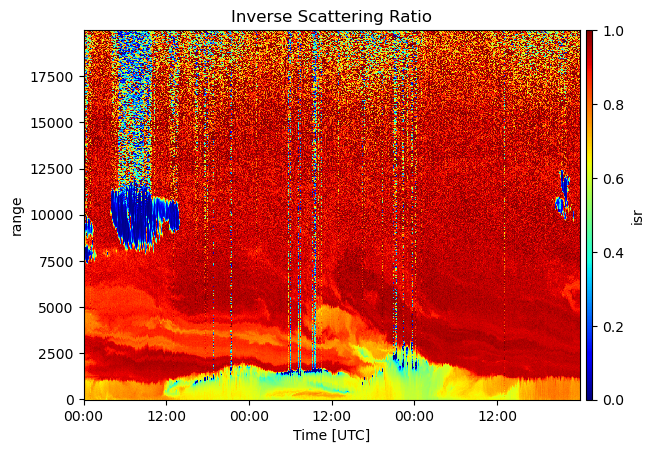

In [574]:
plot_inverse_scattering_ratio(bnf_hsrl_spec_features)

In [16]:
calculate_log_color_ratio(bnf_hsrl_spec_features)
remove_log_color_ratio_threshold(bnf_hsrl_spec_features)

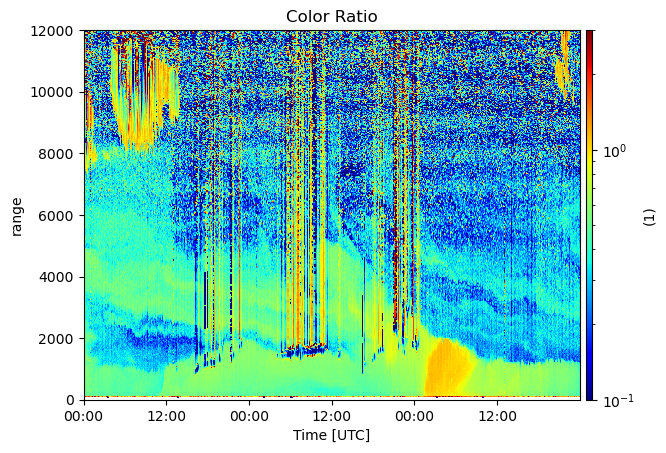

In [576]:
plot_color_ratio(bnf_hsrl_spec_features)

In [17]:
calculate_log_linear_depol(bnf_hsrl_spec_features)
remove_log_linear_depol_threshold(bnf_hsrl_spec_features)

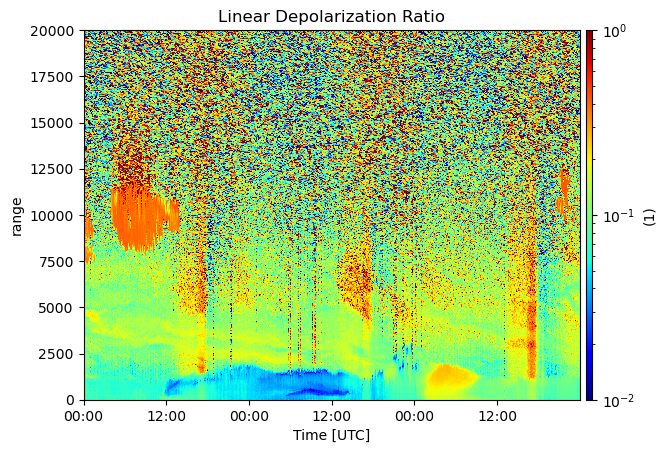

In [578]:
plot_linear_depol_ratio_532(bnf_hsrl_spec_features)

In [20]:
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.colors as mcolors

# # Rebuild the "valid" mask from scratch on the raw data
# # (before remove_negatives was applied — use the original values)
# # Since you've already applied masks in-place, we check NaN in the current dataset

# linear_depol = bnf_hsrl_spec_features['linear_depol'].values
# color_ratio   = bnf_hsrl_spec_features['color_ratio'].values
# isr           = bnf_hsrl_spec_features['isr'].values

# # A pixel is KEPT if all three features are non-NaN
# kept_mask = (~np.isnan(linear_depol)) & (~np.isnan(color_ratio)) & (~np.isnan(isr))

# # Build the curtain array: 1 = kept, 0 = filtered out, NaN = out of range (optional)
# curtain = np.where(kept_mask, 1.0, 0.0)  # shape: (time, range)

# time      = bnf_hsrl_spec_features.time.values.astype('datetime64[s]')
# range_km  = bnf_hsrl_spec_features.range.values / 1000

# fig, ax = plt.subplots(figsize=(16, 5))

# cmap = mcolors.ListedColormap(['#d62728', '#1f77b4'])  # red = filtered, blue = kept
# bounds = [-0.5, 0.5, 1.5]
# norm   = mcolors.BoundaryNorm(bounds, cmap.N)

# p = ax.pcolormesh(
#     time,
#     range_km,
#     curtain.T,
#     cmap=cmap,
#     norm=norm,
#     shading='auto'
# )

# cbar = fig.colorbar(p, ax=ax, ticks=[0, 1], pad=0.01)
# cbar.ax.set_yticklabels(['Filtered out', 'Kept'])

# ax.set_xlabel('Time (UTC)')
# ax.set_ylabel('Range (km)')
# ax.set_ylim(0, 18)
# ax.set_title('Mask Curtain Plot — Kept vs. Filtered-out Pixels')
# fig.autofmt_xdate()
# plt.tight_layout()
# plt.show()

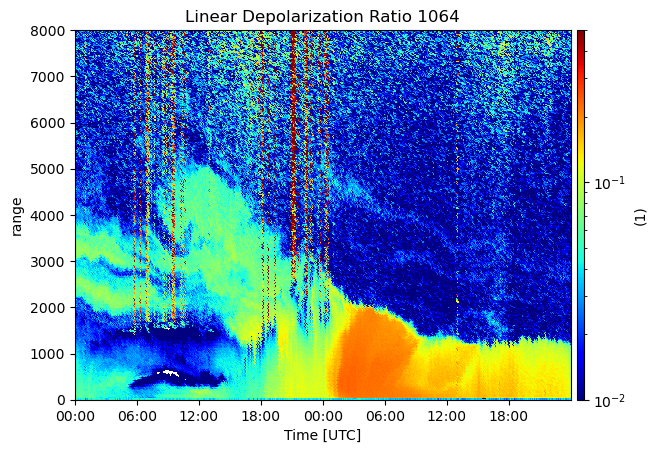

In [560]:
plot_linear_depol_ratio_1064(bnf_hsrl_spec_features)

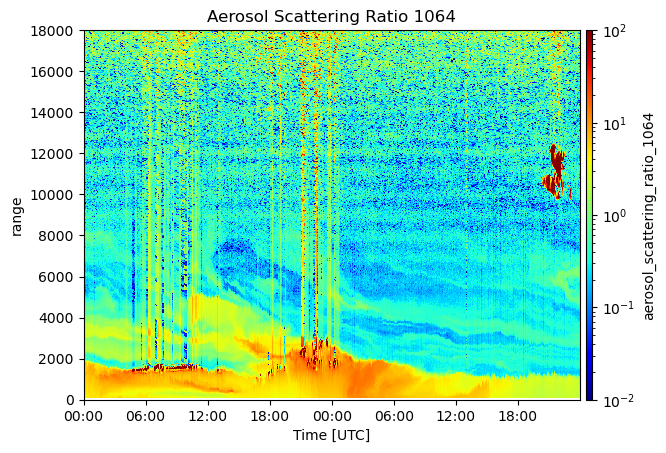

In [538]:
plot_aerosol_scattering_ratio_1064(bnf_hsrl_spec_features)

In [18]:
# Plotting Inverse Scattering Ratio
def plot_attenuated_backscattering_ratio(bnf_hsrl_spec_features):
    display = act.plotting.TimeSeriesDisplay(bnf_hsrl_spec_features)
    display.plot(
        'atten_beta_r_backscatter',
        cmap='jet',
        norm=colors.LogNorm(vmin=3e-7, vmax=3e-6),
        set_title="Attenuated Backscatter Ratio"
    )
    # display.axes[0].set_ylim(0, 8000)
    plt.show()

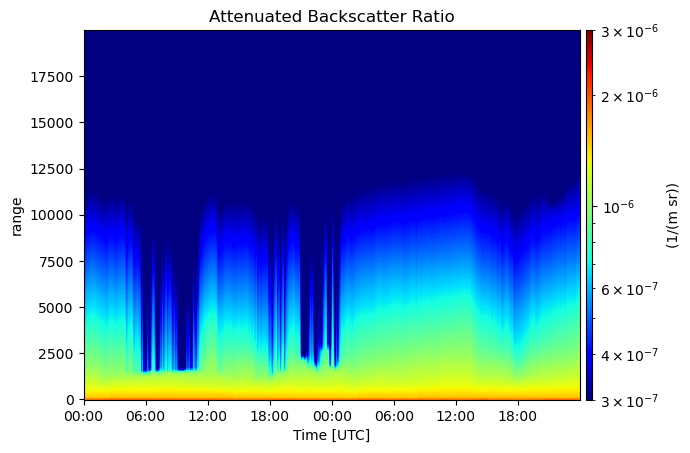

In [13]:
plot_attenuated_backscattering_ratio(bnf_hsrl_spec_features)

### Setup for trying Clustering
We are flattening the features we want for clustering to create 1D Arrays and removing NaN values

In [19]:
def load_ds_with_clustering_features(cluster_features, bnf_hsrl_spec_features):
    hsrl_cluster_ds = bnf_hsrl_spec_features[cluster_features]
    return hsrl_cluster_ds

In [20]:
cluster_features = ["log_linear_depol", "log_color_ratio", "isr"] # we could look at ldr 1064, ratio between two depols, isr 1064
hsrl_cluster_ds = load_ds_with_clustering_features(cluster_features, bnf_hsrl_spec_features)
hsrl_cluster_ds

<xarray.Dataset> Size: 68MB
Dimensions:           (time: 8484, range: 667)
Coordinates:
  * time              (time) datetime64[ns] 68kB 2026-05-12 ... 2026-05-14T23...
  * range             (range) float32 3kB 0.0 30.0 60.0 ... 1.995e+04 1.998e+04
Data variables:
    log_linear_depol  (time, range) float32 23MB dask.array<chunksize=(1, 667), meta=np.ndarray>
    log_color_ratio   (time, range) float32 23MB dask.array<chunksize=(1, 667), meta=np.ndarray>
    isr               (time, range) float32 23MB dask.array<chunksize=(1, 667), meta=np.ndarray>
Attributes: (12/99)
    command_line:                                            hsrl_ingest -s b...
    Conventions:                                             ARM-1.3
    process_version:                                         hsrl-6.2.0
    dod_version:                                             hsrl-a1-3.1
    input_source:                                            /data/collection...
    site_id:                                                 bnf
    ...                                                      ...
    code_version:                                            2.6.7
    history:                                                 created by user ...
    _file_dates:                                             ['20260512', '20...
    _file_times:                                             ['000000', '0000...
    _datastream:                                             bnfhsrlM1.a1
    _arm_standards_flag:                                     1

### Flattening
We are flattening the cluster features so that they are stackable on top of each other to create an input array for our Clustering model

In [21]:
def flatten_features(hsrl_cluster_ds):
    flattened_features = {}
    for feature in cluster_features:
        flattened_features[feature] = hsrl_cluster_ds[feature].values.flatten()
        print(flattened_features[feature].shape)
        
    return flattened_features

In [22]:
flattened_features = flatten_features(hsrl_cluster_ds)
flattened_features

(5658828,)
(5658828,)
(5658828,)


{'log_linear_depol': array([       nan,        nan, -1.37672  , ..., -1.0555027,        nan,
               nan], dtype=float32),
 'log_color_ratio': array([nan, nan, nan, ..., nan, nan, nan], dtype=float32),
 'isr': array([      nan, 0.6928234, 0.6582819, ..., 1.1736106,       nan,
        1.1397537], dtype=float32)}

### Stack the flattened features arrays
We take the flattened array for each feature and then stack them on top of each other to get a new stacked array of features

In [23]:
# Stack and transpose to (n_samples, n_features)
def stack_flattened_features(flattened_features, cluster_features):
    hsrl_arrays = np.array([flattened_features[f] for f in cluster_features]).T
    print(f"Full array shape: {hsrl_arrays.shape}")
    
    # Get boolean mask of rows with no NaNs
    valid_mask = (~np.isnan(hsrl_arrays)).all(axis=1)

    # Store the indices of valid rows
    valid_indices = np.where(valid_mask)[0]
    
    clean_hsrl_arrays = hsrl_arrays[valid_mask]
    print(f"Clean array shape: {clean_hsrl_arrays.shape}")
    print(f"Valid points: {len(valid_indices)}")
    
    return clean_hsrl_arrays, valid_indices

# write code for how many clusters I should get, save in pkl file

### Reconstruct the 2D array with labels
We get the cluster labels and indices of valid data points. The original data points are put in the array with their clustered labels to use it for plotting later

In [24]:
# do the reverse to reconstruct the 2d Array
def reconstruct_2d(labels, indices, original_shape):
    n_total = original_shape[0] * original_shape[1]
    result_flat = np.full(n_total, np.nan)
    result_flat[indices] = labels
    return result_flat.reshape(original_shape)

In [25]:
clean_hsrl_arrays, valid_indices = stack_flattened_features(flattened_features, cluster_features)
# print(hsrl_arrays.shape)
print(clean_hsrl_arrays.shape)

Full array shape: (5658828, 3)
Clean array shape: (3188953, 3)
Valid points: 3188953
(3188953, 3)


In [29]:
# z_scores = np.abs(zscore(clean_hsrl_arrays))
# no_outlier_mask = (z_scores < 3).all(axis=1)
# clean_hsrl_arrays_filtered = clean_hsrl_arrays[no_outlier_mask]
# print(f"Before outlier removal: {clean_hsrl_arrays.shape}")
# print(f"After outlier removal:  {clean_hsrl_arrays_filtered.shape}")

In [26]:
def scale_flattened_features_array(clean_hsrl_arrays):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(clean_hsrl_arrays)
    return scaler, X_scaled

In [27]:
scaler, X_scaled = scale_flattened_features_array(clean_hsrl_arrays)

### Attempting KMeans Clustering

k=2: inertia=6921256.50
k=3: inertia=5314066.00
k=4: inertia=4050680.75
k=5: inertia=3411868.50
k=6: inertia=2809734.50
k=7: inertia=2517509.75
k=8: inertia=2253130.00


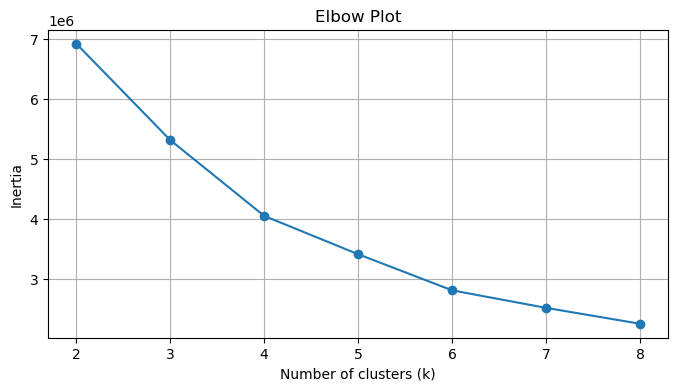

In [33]:
# run elbow plot to see inertia across different k values
inertias = []
ks = range(2, 9)

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    print(f"k={k}: inertia={km.inertia_:.2f}")

plt.figure(figsize=(8, 4))
plt.plot(ks, inertias, 'o-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Plot')
plt.grid(True)
plt.show()

### Silhouette Score
The silhouette score is a metric used to evaluate the quality of K-Means clustering by measuring how similar a point is to its own cluster (cohesion) compared to other clusters (separation). Scores range from \(-1\) to \(+1\), where higher values indicate better-defined, distinct clusters.

k=2: silhouette=0.3825
k=3: silhouette=0.2827
k=4: silhouette=0.3165
k=5: silhouette=0.3028
k=6: silhouette=0.3155
k=7: silhouette=0.3004
k=8: silhouette=0.3095


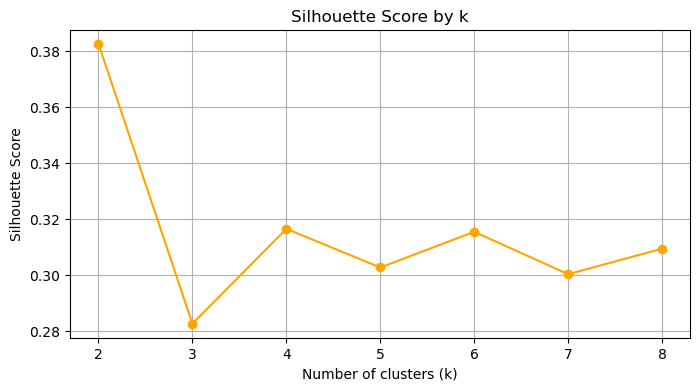

In [34]:
from sklearn.metrics import silhouette_score

sil_scores = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels_k = km.fit_predict(X_scaled)
    idx = np.random.choice(len(X_scaled), size=10_000, replace=False)
    sil = silhouette_score(X_scaled[idx], labels_k[idx])
    sil_scores.append(sil)
    print(f"k={k}: silhouette={sil:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(ks, sil_scores, 'o-', color='orange')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by k')
plt.grid(True)
plt.show()

In [35]:
def run_kmeans_clustering(X_scaled, n_clusters):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto")
    labels = kmeans.fit_predict(X_scaled)
    return kmeans, labels

In [36]:
kmeans, labels = run_kmeans_clustering(X_scaled, 5)
kmeans.cluster_centers_

array([[-0.9897575 ,  0.7185502 , -0.8707168 ],
       [ 1.3842938 ,  1.0080837 , -4.0400553 ],
       [ 1.0877937 ,  1.4420443 ,  0.29235148],
       [-0.6662276 , -1.0364679 ,  0.34019437],
       [ 0.3508883 , -0.14709923,  0.37027854]], dtype=float32)

### Plotting the reconstructed cluster map

In [37]:
clean_hsrl_arrays, valid_indices = stack_flattened_features(flattened_features, cluster_features)
print(f"Clean HSRL Array shape: {clean_hsrl_arrays.shape}")

Full array shape: (5658828, 3)
Clean array shape: (3188953, 3)
Valid points: 3188953
Clean HSRL Array shape: (3188953, 3)


In [38]:
K_OPT=5

In [39]:
scaler, X_scaled = scale_flattened_features_array(clean_hsrl_arrays)
kmeans, labels = run_kmeans_clustering(X_scaled, n_clusters=K_OPT)

# final_indices = valid_indices[no_outlier_mask]
original_shape = bnf_hsrl_spec_features['log_linear_depol'].shape
cluster_map_2d = reconstruct_2d(labels + 1, valid_indices, original_shape)

In [40]:
kmeans.cluster_centers_

array([[-0.98975754,  0.7185502 , -0.87071687],
       [ 1.3842938 ,  1.0080838 , -4.0400553 ],
       [ 1.0877938 ,  1.4420445 ,  0.2923515 ],
       [-0.6662276 , -1.0364679 ,  0.3401944 ],
       [ 0.3508883 , -0.14709923,  0.37027854]], dtype=float32)

In [41]:
cluster_map_2d

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

In [42]:
# Check how many pixels got assigned a cluster
n_assigned = np.sum(~np.isnan(cluster_map_2d))
n_total = cluster_map_2d.size
print(f"Assigned: {n_assigned} / {n_total} ({100 * n_assigned / n_total:.1f}%)")

# Check which cluster labels exist
unique_labels = np.unique(cluster_map_2d[~np.isnan(cluster_map_2d)])
print(f"Unique clusters: {unique_labels}")

# Check cluster counts
for label in unique_labels:
    count = np.sum(cluster_map_2d == label)
    print(f"Cluster {int(label)}: {count} pixels ({100 * count / n_assigned:.1f}%)")

Assigned: 3188953 / 5658828 (56.4%)
Unique clusters: [1. 2. 3. 4. 5.]
Cluster 1: 526682 pixels (16.5%)
Cluster 2: 107528 pixels (3.4%)
Cluster 3: 365011 pixels (11.4%)
Cluster 4: 782503 pixels (24.5%)
Cluster 5: 1407229 pixels (44.1%)


In [41]:
# try dbscan, gmm

In [42]:
# apply screen based an Attenuated Backscatter Ratio. apply screen when ABR gets very low (do curtain plot for threshold): maybe e-5

### Plotting reconstructed 2D Map as clusters

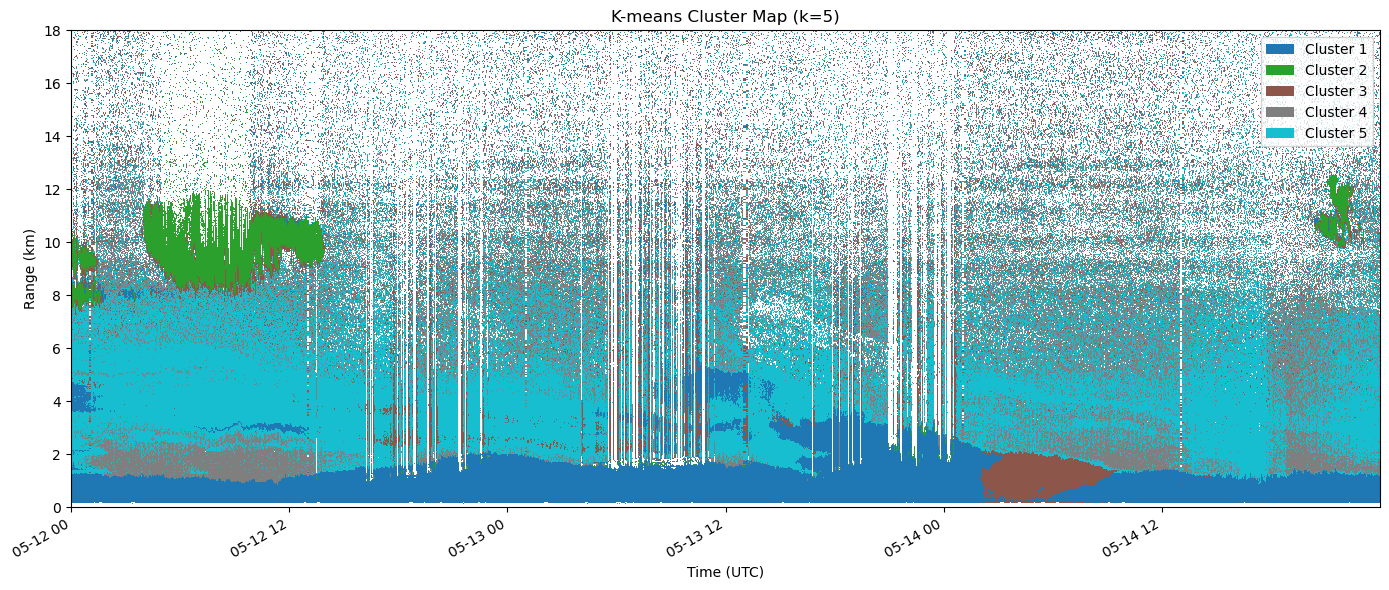

In [43]:
import matplotlib
from matplotlib.patches import Patch

n_clusters = K_OPT
cmap = matplotlib.colormaps['tab10'].resampled(n_clusters)
# cmap='jet'
time = bnf_hsrl_spec_features.time.values.astype('datetime64[s]')
range_km = bnf_hsrl_spec_features.range.values / 1000

fig, ax = plt.subplots(figsize=(14, 6))

p = ax.pcolormesh(
    time,
    range_km,
    cluster_map_2d.T,
    cmap=cmap,
    vmin=0.5,
    vmax=n_clusters + 0.5
)

legend_handles = [
    Patch(facecolor=cmap(i / n_clusters), label=f'Cluster {i+1}')
    for i in range(n_clusters)
]
ax.legend(handles=legend_handles, loc='upper right', framealpha=0.8)
ax.set_xlabel('Time (UTC)')
ax.set_ylabel('Range (km)')
ax.set_ylim(0, 18)
ax.set_title(f'K-means Cluster Map (k={n_clusters})')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Running HDBScan

In [40]:
from sklearn.cluster import HDBSCAN

def run_hdbscan_clustering(X_scaled, min_cluster_size=500, min_samples=10):
    hdbscan = HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples, n_jobs=-1)
    labels = hdbscan.fit_predict(X_scaled)
    
    n_clusters = len(np.unique(labels[labels >= 0]))
    n_noise    = np.sum(labels == -1)
    print(f"Clusters found: {n_clusters}")
    print(f"Noise points:   {n_noise} ({100 * n_noise / len(labels):.1f}%)")
    
    return hdbscan, labels

In [ ]:
hdbscan, labels = run_hdbscan_clustering(X_scaled)

In [ ]:
# import matplotlib
# from matplotlib.patches import Patch

# n_clusters_db = len(np.unique(labels_db[labels_db >= 0]))
# cmap = matplotlib.colormaps['tab10'].resampled(n_clusters_db)

# time = bnf_hsrl_spec_features.time.values.astype('datetime64[s]')
# range_km = bnf_hsrl_spec_features.range.values / 1000

# fig, ax = plt.subplots(figsize=(14, 6))
# p = ax.pcolormesh(
#     time,
#     range_km,
#     cluster_map_dbscan.T,
#     cmap=cmap,
#     vmin=0.5,
#     vmax=n_clusters_db + 0.5
# )

# legend_handles = [
#     Patch(facecolor=cmap(i / n_clusters_db), label=f'Cluster {i+1}')
#     for i in range(n_clusters_db)
# ]
# ax.legend(handles=legend_handles, loc='upper right', framealpha=0.8)
# ax.set_xlabel('Time (UTC)')
# ax.set_ylabel('Range (km)')
# ax.set_ylim(0, 8)
# ax.set_title('DBSCAN Cluster Map')
# fig.autofmt_xdate()
# plt.tight_layout()
# plt.show()

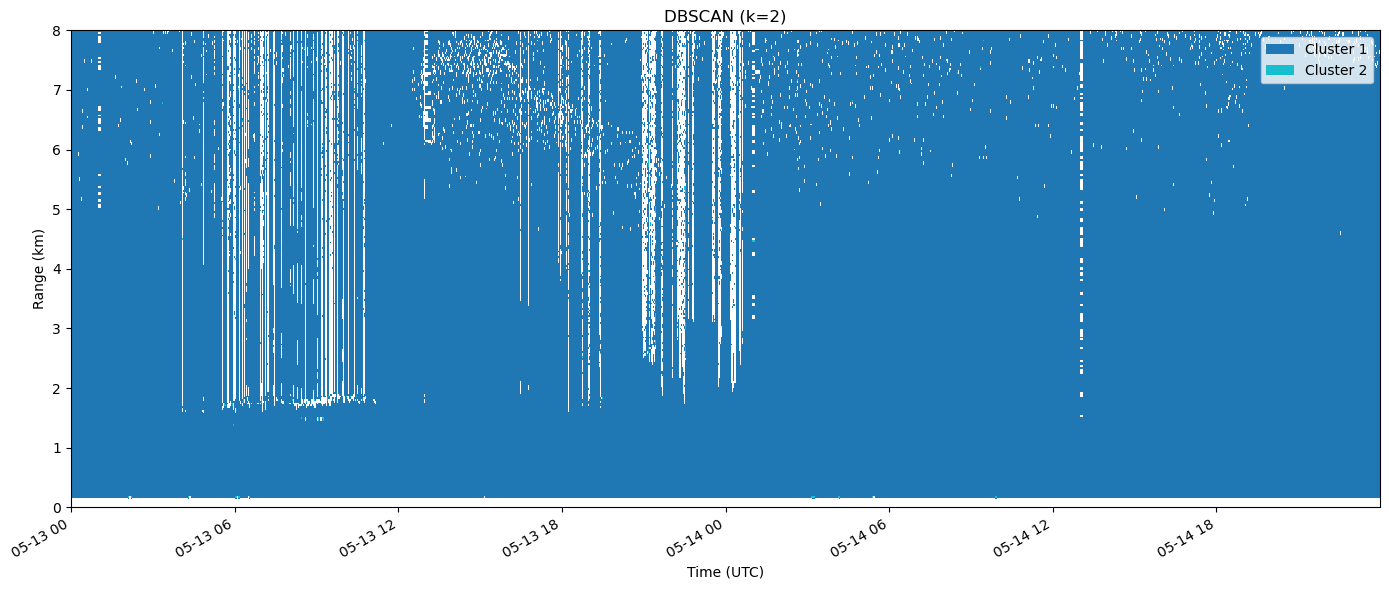

In [62]:
# import matplotlib
# from matplotlib.patches import Patch

# n_clusters = 2
# cmap = matplotlib.colormaps['tab10'].resampled(n_clusters)

# time = bnf_hsrl_spec_features.time.values.astype('datetime64[s]')
# range_km = bnf_hsrl_spec_features.range.values / 1000

# fig, ax = plt.subplots(figsize=(14, 6))

# p = ax.pcolormesh(
#     time,
#     range_km,
#     cluster_map_2d.T,
#     cmap=cmap,
#     vmin=0.5,
#     vmax=n_clusters + 0.5
# )

# legend_handles = [
#     Patch(facecolor=cmap(i / n_clusters), label=f'Cluster {i+1}')
#     for i in range(n_clusters)
# ]
# ax.legend(handles=legend_handles, loc='upper right', framealpha=0.8)
# ax.set_xlabel('Time (UTC)')
# ax.set_ylabel('Range (km)')
# ax.set_ylim(0, 8)
# ax.set_title(f'DBSCAN (k={n_clusters})')
# fig.autofmt_xdate()
# plt.tight_layout()
# plt.show()